<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
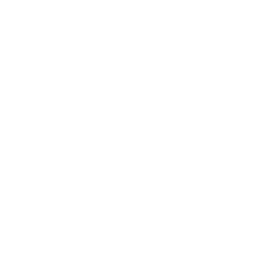
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Asiakkaiden riskiprofilointi kanonisen erotteluanalyysin avulla</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Rahoituspalvelut / Luottoriskianalytiikka &nbsp;|&nbsp; Maaliskuu 2026</p>
</div>
</div>
</div>

## Yhteenveto

Kolme lainan tila -ryhmää kuluttajien asuntolainasalkussa — **maksuhäiriöiset**, **normaalit** ja **ennenaikaisesti takaisin maksetut** — eroavat toisistaan usean taloudellisen terveyden ulottuvuuden suhteen samanaikaisesti, mikä tekee mistä tahansa yksittäisestä tunnusluvusta heikon riskisignaalin. Tässä muistikirjassa sovelletaan **PROC CANDISC** -proseduuria (kanoninen erotteluanalyysi) 100 asiakkaan riskitarkasteluotokseen ja tiivistetään kuusi keskenään korreloivaa taloudellista tunnuslukua kahteen kanoniseen ulottuvuuteen, jotka maksimoivat kolmen tilaryhmän välisen erottelun.

Ensimmäinen kanoninen ulottuvuus kantaa lähes koko ryhmien välisen erottelun — kanoninen korrelaatio **0.958**, joka jakaa **91.8 %** varianssistaan ryhmäjäsenyyden kanssa — ja järjestää lainanottajat siististi maksuhäiriöisistä toisessa ääripäässä ennenaikaisesti takaisin maksaneisiin toisessa. Toinen ulottuvuus (kanoninen korrelaatio **0.503**, neliöity **0.254**) tuo toissijaisen kontrastin, jota johtavat maksuhäiriöhistoria ja velkaantuneisuus. Neliöidyt Mahalanobis-etäisyydet vahvistavat, että **DEFAULT**- ja **PREPAID**-keskipisteet ovat kauimpana toisistaan oleva pari (**75.3**), ja **CURRENT** sijaitsee niiden välissä (34.3 DEFAULT-ryhmästä, 10.1 PREPAID-ryhmästä). Näin saadut kanoniset pistemäärät muodostavat tiiviin yhdistetyn riski-indeksin, joka soveltuu salkun segmentointiin ja pisteytyskortin kalibrointiin.

## Tietolähteet

| Lähde | Kuvaus | Tietueita |
|--------|-------------|--------|
| WORK.LOAN_PROFILES | Synteettiset asiakkaiden taloudelliset tunnusluvut ja käyttäytymismittarit, merkitty lainan tilan mukaan, poimittu tasapainotettuna riskitarkasteluotoksena | 100 |

Otoksessa maksuhäiriöiset ja ennenaikaisesti takaisin maksetut tilit ovat tarkoituksellisesti yliedustettuina (tapaus–verrokki-tyylinen poiminta), jotta jokainen tilaryhmä on riittävän suuri vakaan ryhmänsisäisen kovarianssirakenteen estimointiin erotteluanalyysia varten.

---

In [1]:
/* --------------------------------------------------------
   Luo synteettinen lainaasiakkaiden riskikatselmusotos.
   Kolme tilaryhmää (DEFAULT / CURRENT / PREPAID) ylinäytteistetään
   riskihäntiin päin, jotta jokainen luokka on riittävän suuri
   vakaalle ryhmän sisäiselle kovarianssiestimaatille.
   HUOM: luokka-arvot pidetään ASCII-muodossa, koska PROC CANDISC
   (design-matriisiproseduuri) ei siedä ei-ASCII-luokkatasoja.
   -------------------------------------------------------- */
TIEDOT work.loan_profiles;
    CALL streaminit(42);
    PITUUS loan_status $10 vintage $7 customer_id $12;
    TAULUKKO statuses[3] $10 _temporary_ ('DEFAULT' 'CURRENT' 'PREPAID');
    TAULUKKO vintages[4] $7 _temporary_ ('2022-Q1' '2022-Q3' '2023-Q1' '2023-Q3');
    NIMIKE loan_status='Lainan tila'
           vintage='Myöntämisajankohta'
           customer_id='Asiakastunnus'
           dti_ratio='Velka-tulosuhde (DTI)'
           ltv_ratio='Laina-arvo-suhde (LTV)'
           payment_to_income='Maksu-tulosuhde'
           credit_utilization='Luoton käyttöaste'
           savings_balance='Säästösaldo'
           months_delinquent='Erääntyneitä kuukausia';
    TEE i = 1 ASTI 20000;
        customer_id = cat('CUST-', KIRJOITA(i, z6.));
        vintage = vintages[int(rand('uniform') * 4) + 1];
        status_prob = rand('uniform');
        JOS status_prob < 0.30 NIIN status_idx = 1;       /* DEFAULT */
        MUUTEN JOS status_prob < 0.70 NIIN status_idx = 2;  /* CURRENT */
        MUUTEN status_idx = 3;                             /* PREPAID */
        loan_status = statuses[status_idx];
        /* Tunnusluvut erottavat kolme tilaryhmää */
        JOS loan_status = 'DEFAULT' NIIN TEE;
            dti_ratio          = rand('normal', 0.58, 0.12);
            ltv_ratio          = rand('normal', 0.92, 0.10);
            payment_to_income  = rand('normal', 0.42, 0.08);
            credit_utilization = rand('normal', 0.85, 0.10);
            months_delinquent  = int(rand('exponential') * 4) + 1;
            savings_balance    = rand('exponential') * 4000 + 200;
        LOPPU;
        MUUTEN JOS loan_status = 'CURRENT' NIIN TEE;
            dti_ratio          = rand('normal', 0.35, 0.10);
            ltv_ratio          = rand('normal', 0.78, 0.09);
            payment_to_income  = rand('normal', 0.28, 0.07);
            credit_utilization = rand('normal', 0.45, 0.15);
            months_delinquent  = 0;
            savings_balance    = rand('exponential') * 8000 + 200;
        LOPPU;
        MUUTEN TEE;
            dti_ratio          = rand('normal', 0.22, 0.07);
            ltv_ratio          = rand('normal', 0.60, 0.12);
            payment_to_income  = rand('normal', 0.20, 0.05);
            credit_utilization = rand('normal', 0.25, 0.12);
            months_delinquent  = 0;
            savings_balance    = rand('exponential') * 16000 + 500;
        LOPPU;
        /* Pyöristä ja rajoita tunnusluvut kelvollisiin väleihin */
        dti_ratio          = round(dti_ratio, 0.001);
        ltv_ratio          = round(ltv_ratio, 0.001);
        payment_to_income  = round(payment_to_income, 0.001);
        credit_utilization = round(credit_utilization, 0.001);
        savings_balance    = round(savings_balance, 0.01);
        JOS dti_ratio < 0.05 NIIN dti_ratio = 0.05;
        JOS dti_ratio > 0.99 NIIN dti_ratio = 0.99;
        JOS ltv_ratio < 0.10 NIIN ltv_ratio = 0.10;
        JOS ltv_ratio > 1.20 NIIN ltv_ratio = 1.20;
        JOS credit_utilization < 0.01 NIIN credit_utilization = 0.01;
        JOS credit_utilization > 0.99 NIIN credit_utilization = 0.99;
        TULOSTE;
    LOPPU;
    POISTA i status_prob status_idx;
SUORITA;


NOTE: DATA work.loan_profiles

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.loan_profiles (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  7.35 seconds
  cpu   7.35 seconds


---

### Ryhmien perusprofiilit

Ennen tunnuslukujen tiivistämistä tiivistetään, miten kolme tilaryhmää eroavat toisistaan yksi muuttuja kerrallaan, ja varmistetaan otoksen koostumus eri myöntövuosikertojen välillä.

                                    Tunnuslukujen perusjakaumat lainan tilan mukaan                                     

                                                  The MEANS Procedure

                                  Analysis Variable : dti_ratio Velka-tulosuhde (DTI)

        Lainan tila          N Obs           Mean        Std Dev
        --------------------------------------------------------
        CURRENT                 46          0.331          0.112
        DEFAULT                 29          0.570          0.114
        PREPAID                 25          0.216          0.056
        --------------------------------------------------------

                                  Analysis Variable : ltv_ratio Laina-arvo-suhde (LTV)

        Lainan tila          N Obs           Mean        Std Dev
        --------------------------------------------------------
        CURRENT                 46          0.776          0.080
        DEFAULT                 29          0.


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_vintage_loan_status.spec.json
NOTE: PROC FREQ statement used.


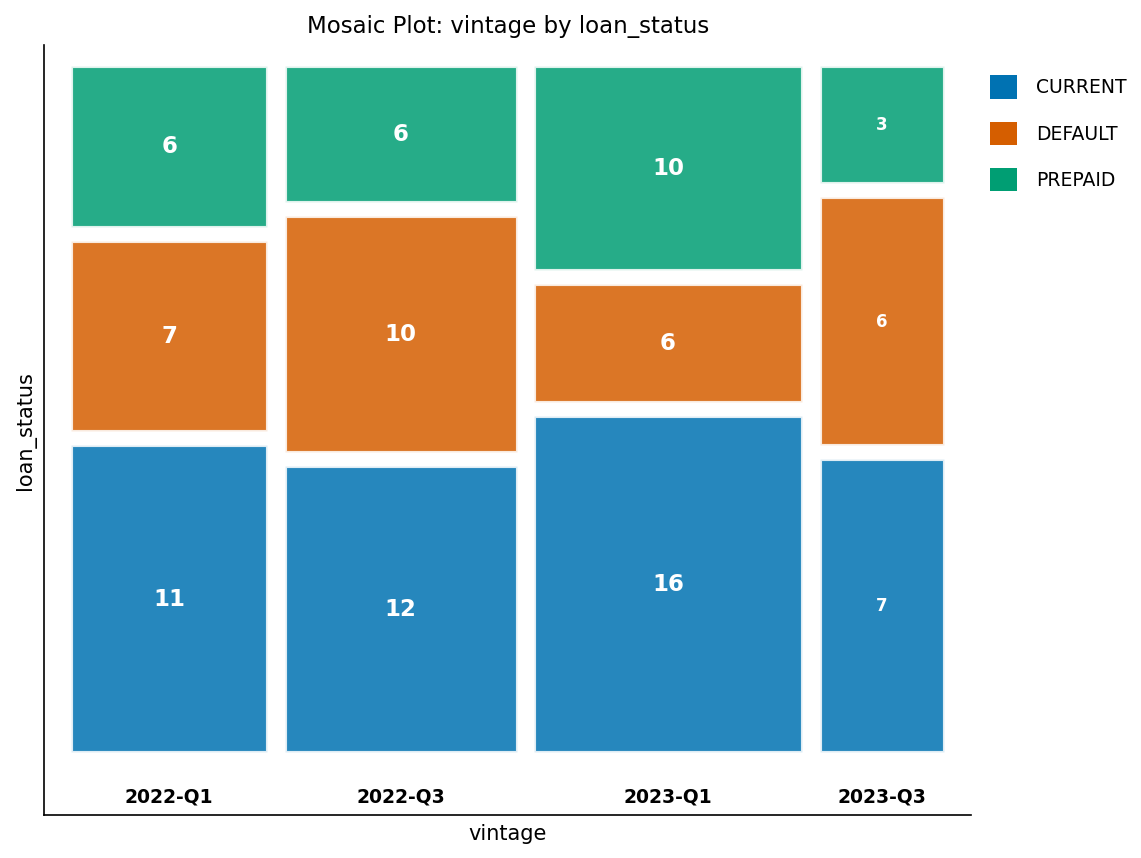

In [2]:
/* --------------------------------------------------------
   Tunnuslukujen perusjakaumat lainan tilan mukaan
   -------------------------------------------------------- */
PROSEDUURI KESKIARVOT TIEDOT=work.loan_profiles n mean std maxdec=3;
    LUOKKA loan_status;
    MUUTTUJA dti_ratio ltv_ratio payment_to_income credit_utilization
        savings_balance months_delinquent;
    OTSIKKO 'Tunnuslukujen perusjakaumat lainan tilan mukaan';
SUORITA;

/* --------------------------------------------------------
   Otoksen koostumus myöntämisajankohdan ja tilan mukaan
   -------------------------------------------------------- */
PROSEDUURI FREKVENSSIT TIEDOT=work.loan_profiles;
    TABLES vintage * loan_status / nocum nopercent;
    OTSIKKO 'Otoksen koostumus myöntämisajankohdan ja tilan mukaan';
SUORITA;

---

### Kanoninen erotteluanalyysi

Sovitetaan yksi yhdistetty kanoninen erottelumalli kaikkien 100 asiakkaan yli. `OUT=` kirjoittaa asiakaskohtaiset kanoniset pistemäärät, `OUTSTAT=` tallentaa kanonisen rakenteen, ryhmien keskipisteet ja neliöidyt Mahalanobis-etäisyydet, ja `DISTANCE` pyytää ryhmien väliset etäisyydet. Ilmoitettu proseduuri on tässä juuri se, joka suoritetaan: **PROC CANDISC**.

                                 Otoksen koostumus myöntämisajankohdan ja tilan mukaan                                  




NOTE: ODS OUTPUT: CANONICALCORRELATIONS -> can_corr
NOTE: PROC CANDISC data=work.loan_profiles ncan=Some(2) prefix=Can

NOTE: Using Python/scikit-learn for canonical discriminant analysis
NOTE: Number of Observations: 100
NOTE: Number of Classes: 3
NOTE: Class Level Information:
NOTE:   CURRENT: 46
NOTE:   DEFAULT: 29
NOTE:   PREPAID: 25
NOTE: Canonical Correlations:
NOTE:   Can1: 0.958136
NOTE:   Can2: 0.503509
NOTE: Eigenvalues of Inv(E)*H:
NOTE:                          Canonical  Approximate  Squared
NOTE:               Eigenvalue Correlation  Std Error Correlation
NOTE:   Can1       11.198645    0.958136            0.918024
NOTE:   Can2        0.339624    0.503509            0.253522
NOTE: Multivariate Statistics and F Approximations:
NOTE:   Statistic                Value     F Value  Num DF  Den DF  Pr > F
NOTE:   Wilks' Lambda         0.061194     46.65      12   184.0   0.0000
NOTE:   Pillai's Trace        1.171545     21.68      12   184.0   0.0000
NOTE:   Hotelling-Lawley  

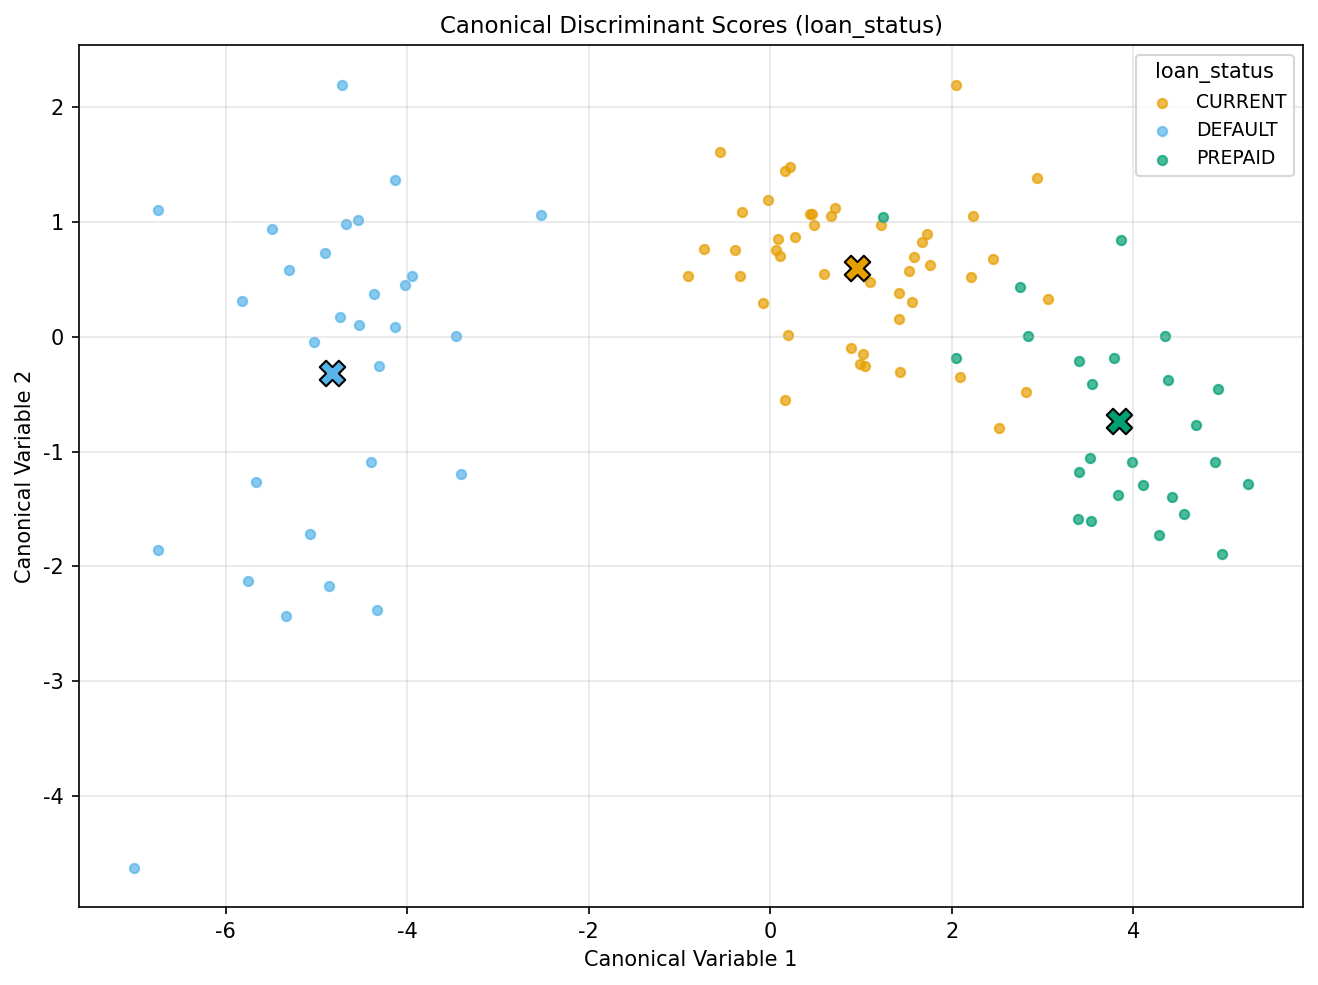

In [3]:
/* --------------------------------------------------------
   Lainan tila -ryhmien kanoninen erotteluanalyysi.
   OUT=    asiakaskohtaiset kanoniset pisteet (Can1, Can2)
   OUTSTAT= rakenne, luokkien keskiarvot, Mahalanobis-etäisyydet
   -------------------------------------------------------- */
ODS TULOSTE CanonicalCorrelations=work.can_corr;

PROSEDUURI CANDISC TIEDOT=work.loan_profiles
    out=work.risk_scores
    OUTSTAT=work.can_stat
    ncan=2
    distance;
    LUOKKA loan_status;
    MUUTTUJA dti_ratio ltv_ratio payment_to_income credit_utilization
        savings_balance months_delinquent;
    OTSIKKO 'Lainan tila -ryhmien kanoninen riskierottelu';
SUORITA;

ODS TULOSTE CLOSE;

---

### Kanoniset korrelaatiot

Kuinka suuren osan kolmen ryhmän välisestä erottelusta kukin kanoninen ulottuvuus tavoittaa.

In [4]:
PROSEDUURI TULOSTA TIEDOT=work.can_corr noobs;
    OTSIKKO 'Kanoniset korrelaatiot';
SUORITA;

                                                 Kanoniset korrelaatiot                                                 

CANONICAL_VARIABLE  CANONICAL_CORRELATION  SQUARED_CANONICAL_CORRELATION     EIGENVALUE
Can1                         0.9581355246                   0.9180236835  11.1986452089
Can2                          0.503509317                   0.2535216323   0.3396235488




NOTE: PROC PRINT data=work.can_corr

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


### Kanoninen rakenne (muuttujien lataukset)

Kunkin alkuperäisen taloudellisen tunnusluvun korrelaatio kahden kanonisen ulottuvuuden kanssa — näin ulottuvuuksia tulkitaan.

In [5]:
PROSEDUURI TULOSTA TIEDOT=work.can_stat noobs label;
    MISSÄ _type_ = 'STRUCTUR';
    MUUTTUJA _name_ Can1 Can2;
    NIMIKE Can1='Kanoninen 1' Can2='Kanoninen 2';
    OTSIKKO 'Yhdistetty luokan sisäinen kanoninen rakenne';
SUORITA;

                                      Yhdistetty luokan sisäinen kanoninen rakenne                                      

            _NAME_  Kanoninen 1  Kanoninen 2
dti_ratio             -0.403583    -0.022755
ltv_ratio             -0.369749     0.732657
payment_to_income     -0.304192     0.117008
credit_utilization    -0.595076    -0.056264
savings_balance         0.12558     0.093182
months_delinquent     -0.323965    -0.699884




NOTE: PROC PRINT data=work.can_stat

NOTE: PROC PRINT completed: 6 observations printed, 3 variables


### Ryhmien keskipisteet ja Mahalanobis-etäisyydet

Ryhmien keskiarvot kanonisilla akseleilla (ryhmien keskipisteet) ja neliöidyt Mahalanobis-etäisyydet kunkin ryhmäparin välillä — riskipistemäärän kalibroinnin perusta.

In [6]:
PROSEDUURI TULOSTA TIEDOT=work.can_stat noobs label;
    MISSÄ _type_ SISÄLLÄ ('CANMEAN' 'DIST');
    MUUTTUJA _type_ _name_ Can1 Can2;
    NIMIKE Can1='Kanoninen 1' Can2='Kanoninen 2';
    OTSIKKO 'Ryhmien keskipisteet (CANMEAN) ja neliöidyt Mahalanobis-etäisyydet (DIST)';
SUORITA;

                       Ryhmien keskipisteet (CANMEAN) ja neliöidyt Mahalanobis-etäisyydet (DIST)                        

 _TYPE_              _NAME_  Kanoninen 1  Kanoninen 2
CANMEAN  CURRENT                0.956102      0.59917
CANMEAN  DEFAULT               -4.826727    -0.316237
CANMEAN  PREPAID                3.839776    -0.735639
DIST     CURRENT to DEFAULT    34.279058            .
DIST     CURRENT to PREPAID    10.097273            .
DIST     DEFAULT to PREPAID    75.284092            .




NOTE: PROC PRINT data=work.can_stat

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

### Kanoninen erottelukartta

Jokainen asiakas piirretty kaksiulotteiseen kanoniseen avaruuteen, väritettynä lainan tilan mukaan. Hyvin erottuvat rypäät osoittavat, että kanoniset pistemäärät kantavat vahvaa ryhmätietoa.

                       Ryhmien keskipisteet (CANMEAN) ja neliöidyt Mahalanobis-etäisyydet (DIST)                        




NOTE: PROC SGPLOT data=work.risk_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


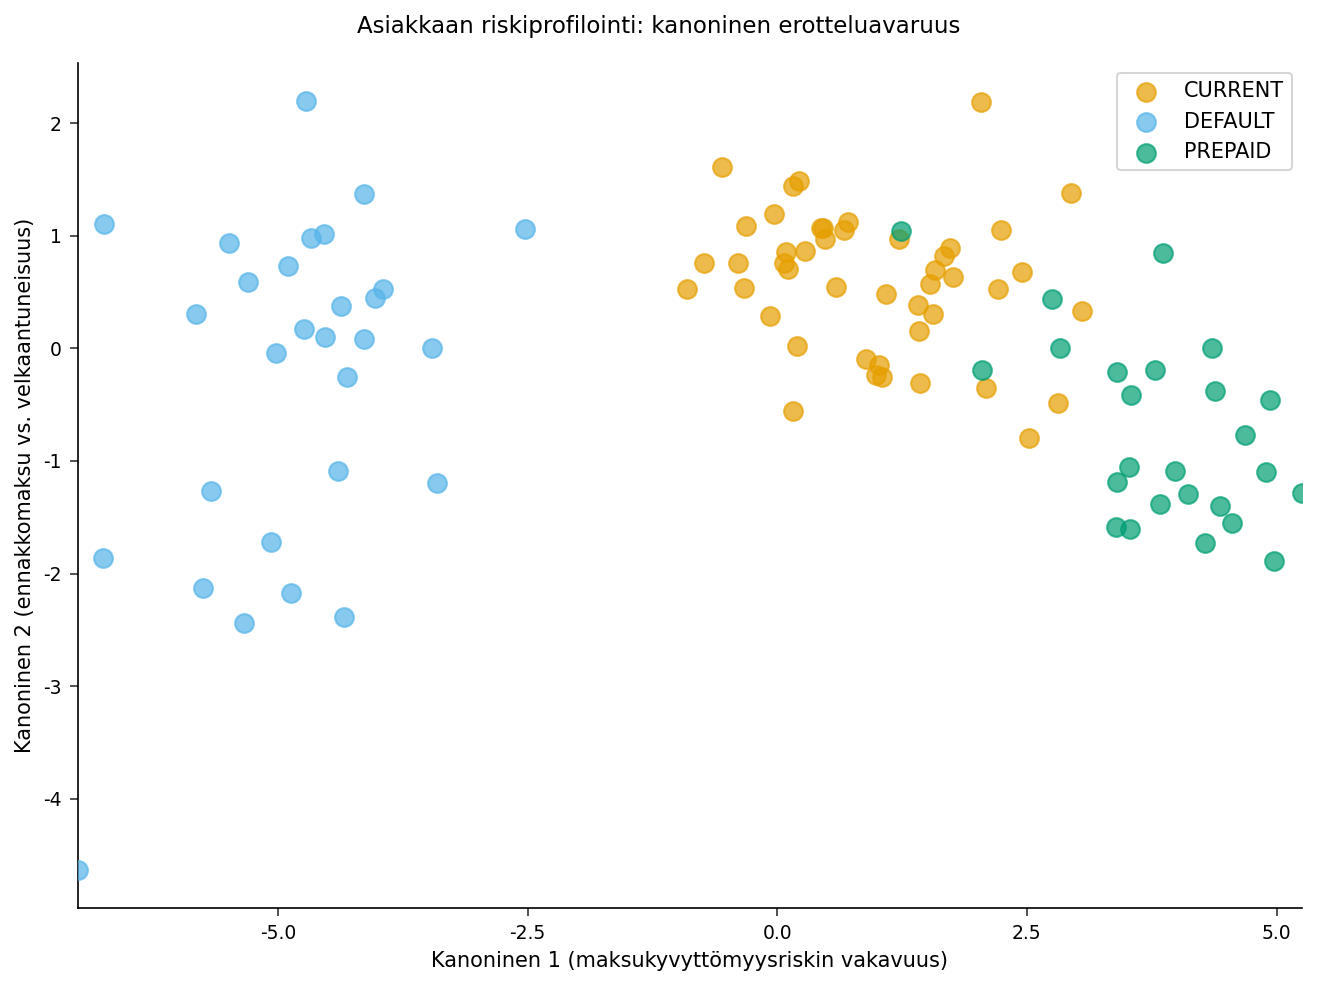

In [7]:
PROSEDUURI SGPLOT TIEDOT=work.risk_scores;
    SCATTER x=Can1 y=Can2 / GROUP=loan_status
        MARKERATTRS=(SYMBOL=circlefilled size=9)
        TRANSPARENCY=0.3;
    XAXIS NIMIKE='Kanoninen 1 (maksukyvyttömyysriskin vakavuus)';
    YAXIS NIMIKE='Kanoninen 2 (ennakkomaksu vs. velkaantuneisuus)';
    OTSIKKO 'Asiakkaan riskiprofilointi: kanoninen erotteluavaruus';
SUORITA;

---

### Tulkinta

Kaksi kanonista ulottuvuutta erottavat kolme lainan tila -ryhmää selkeästi tässä 100 asiakkaan otoksessa (46 normaalia, 29 maksuhäiriöistä, 25 ennenaikaisesti takaisin maksettua).

**Ulottuvuus 1 — maksuhäiriöriskin vakavuus (kanoninen korrelaatio 0.958, 91.8 % jaettua varianssia).** Tämä akseli yksin selittää valtaosan ryhmien erottelusta (ominaisarvo 11.20 verrattuna toisen akselin arvoon 0.34). Yhdistetyssä luokkien sisäisessä kanonisessa rakenteessa se latautuu voimakkaimmin luoton käyttöasteeseen (-0.595), velan suhteeseen tuloihin (-0.404), LTV-suhteeseen (-0.370), maksuhäiriökuukausiin (-0.324) ja maksun suhteeseen tuloihin (-0.304) — jokainen velkaantuneisuuden ja taakan mittari osoittaa samaan suuntaan. Koska lataukset ovat negatiivisia, matalat (negatiivisemmat) Can1-pistemäärät merkitsevät korkeimman riskin lainanottajia. Ryhmien keskipisteet vahvistavat tämän: maksuhäiriöiset tilit sijaitsevat kohdassa Can1 = -4.83, normaalit tilit kohdassa +0.96 ja ennenaikaisesti takaisin maksetut kohdassa +3.84 — siisti monotoninen järjestys huonoimmasta parhaaseen luottoterveyteen.

**Ulottuvuus 2 — velkaantuneisuus vastaan maksuhäiriöt (kanoninen korrelaatio 0.503).** Toinen akseli asettaa vastakkain LTV-suhteen (+0.733) ja maksuhäiriökuukaudet (-0.700): se erottaa voimakkaasti velkaantuneet mutta normaalit lainanottajat niistä, joilla on maksuhäiriöitä. Se tarkentaa kuvaa Can1:n sisällä mutta tuo huomattavasti vähemmän erottelua, kuten hyvin suoriutuvien ryhmien lähes yhtä suuret Can2-keskipisteet osoittavat (normaalit +0.599, ennenaikaisesti takaisin maksetut -0.736).

**Ryhmien erottelu.** Ryhmien keskiarvojen väliset neliöidyt Mahalanobis-etäisyydet määrittävät erot: DEFAULT–PREPAID on suurin arvolla 75.3, DEFAULT–CURRENT on 34.3 ja CURRENT–PREPAID on pienin arvolla 10.1. Kaksi hyvin suoriutuvaa ryhmää ovat siten lähempänä toisiaan kuin kumpikaan on maksuhäiriöistä ryhmää, juuri kuten lainanantaja odottaisi.

**Käytännön hyöty.** Ensimmäinen kanoninen pistemäärä toimii kuin valmis yhdistetty riski-indeksi: se tiivistää kuusi korreloivaa tunnuslukua yhdeksi hyvin erottuvaksi ulottuvuudeksi, joka järjestää asiakkaat korkeimmasta matalimpaan maksuhäiriöriskiin. Salkkutiimit voivat segmentoida Can1:n raja-arvojen mukaan, ja Mahalanobis-etäisyydet antavat perustellun pohjan uuden hakijan sijoittamiseksi lähimpään tilaryhmään pisteytyskortin kalibroinnin aikana.

---

### Vienti pisteytysmoottoria varten

Tallennetaan asiakaskohtaiset kanoniset pistemäärät ja kanonisten tilastojen aineisto (joka sisältää keskipisteet ja Mahalanobis-etäisyydet) myöhempää pisteytyskortin kalibrointia varten.

In [8]:
/* --------------------------------------------------------
   Vie kanoniset riskipisteet ja kanoniset tilastot
   -------------------------------------------------------- */
PROSEDUURI VIE TIEDOT=work.risk_scores
    OUTFILE='customer_risk_canonical_scores.csv'
    DBMS=csv REPLACE;
SUORITA;

PROSEDUURI VIE TIEDOT=work.can_stat
    OUTFILE='canonical_statistics.csv'
    DBMS=csv REPLACE;
SUORITA;


NOTE: PROC EXPORT data=work.risk_scores outfile=customer_risk_canonical_scores.csv

NOTE: Exported 100 rows to customer_risk_canonical_scores.csv.
NOTE: PROC EXPORT data=work.can_stat outfile=canonical_statistics.csv

NOTE: Exported 31 rows to canonical_statistics.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Luottamuksellinen
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Toteutettu <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>-alustalla
</div>
</div>